# Hospital360 Python EDA
## Portfolio Dataset — 5,000 Synthetic Patients

This notebook analyzes synthetic Synthea healthcare activity, not real hospital or patient data. It demonstrates analytical methodology; results are not clinical conclusions, and claim/activity measures are not hospital P&L or profitability. Association does not imply causation.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.analytics.associations import correlation_table
from src.analytics.db import query_dataframe
from src.analytics.distributions import concentration_shares, lorenz_curve, robust_summary
from src.analytics.outliers import outlier_profile
from src.analytics.profiling import validate_baseline
from src.analytics.trends import add_monthly_diagnostics, volatility_summary

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.4f}'.format
RANDOM_SEED = 20260830

## 1. Read-only connection and baseline gate

Database access uses environment variables from the ignored `.env` file and enforces PostgreSQL `default_transaction_read_only=on`. The EDA stops if any committed 5K fact count or financial total differs.

In [2]:
baseline = validate_baseline()
print('Baseline validation:', 'PASS' if baseline.passed else 'FAIL')
display(pd.Series(baseline.counts, name='rows').to_frame())
display(pd.Series(baseline.financials, name='validated_total').to_frame())

Baseline validation: PASS


,rows
fact_encounter,253563
fact_claim,435751
fact_claim_transaction,3966064
fact_condition_occurrence,159348
fact_procedure,696202


,validated_total
encounter_base_cost,"28,981,362.0400"
encounter_total_claim_cost,"731,937,228.1400"
encounter_payer_coverage,"526,304,744.5400"
transaction_amount,"837,678,683.7600"
transaction_payments,"697,790,613.6700"
transaction_transfers,"279,776,140.1800"
procedure_base_cost,"716,784,016.7400"


## 2. Encounter distributions

The encounter fact is a bounded 253,563-row extract. Duration and financial fields remain at encounter grain; no claim or transaction rows are joined into it.

In [3]:
encounters = query_dataframe("""
SELECT encounter_fact_key, encounter_id, patient_key, provider_key, organization_key, payer_key,
       encounter_class,
       extract(epoch FROM (stop_at - start_at)) / 60.0 AS duration_minutes,
       base_encounter_cost, total_claim_cost, payer_coverage
FROM analytics.fact_encounter
""")
encounters_per_patient = encounters.groupby('patient_key', as_index=False).agg(encounters=('encounter_fact_key', 'size'))
encounter_profiles = pd.concat({
    'encounters_per_patient': robust_summary(encounters_per_patient['encounters']),
    'duration_minutes': robust_summary(encounters['duration_minutes']),
    'base_encounter_cost': robust_summary(encounters['base_encounter_cost']),
    'total_claim_cost': robust_summary(encounters['total_claim_cost']),
}, axis=1)
display(encounter_profiles)
display(pd.DataFrame({
    'duration': outlier_profile(encounters['duration_minutes']),
    'total_claim_cost': outlier_profile(encounters['total_claim_cost']),
}))

,encounters_per_patient,duration_minutes,base_encounter_cost,total_claim_cost
count,"5,000.0000","253,563.0000","253,563.0000","253,563.0000"
mean,50.7126,321.1368,114.2965,"2,886.6090"
std,74.0071,"2,977.5291",27.3382,"7,399.0296"
min,1.0000,15.0000,75.0000,75.0000
p01,6.0000,15.0000,85.5500,85.5500
p05,13.0000,15.0000,85.5500,85.5500
p25,23.0000,15.0000,85.5500,516.9500
median,34.0000,41.9000,136.8000,919.9000
p75,53.0000,125.0000,142.5800,"2,673.9500"
p95,106.0000,239.0000,142.5800,"12,250.4170"


,duration,total_claim_cost
iqr_lower_bound,-150.0000,"-2,718.5500"
iqr_upper_bound,290.0000,"5,909.4500"
low_outliers,0.0000,0.0000
high_outliers,"10,247.0000","25,555.0000"
outlier_share,0.0404,0.1008
p99_threshold,"6,471.0000","37,200.2486"
above_p99,"2,535.0000","2,536.0000"


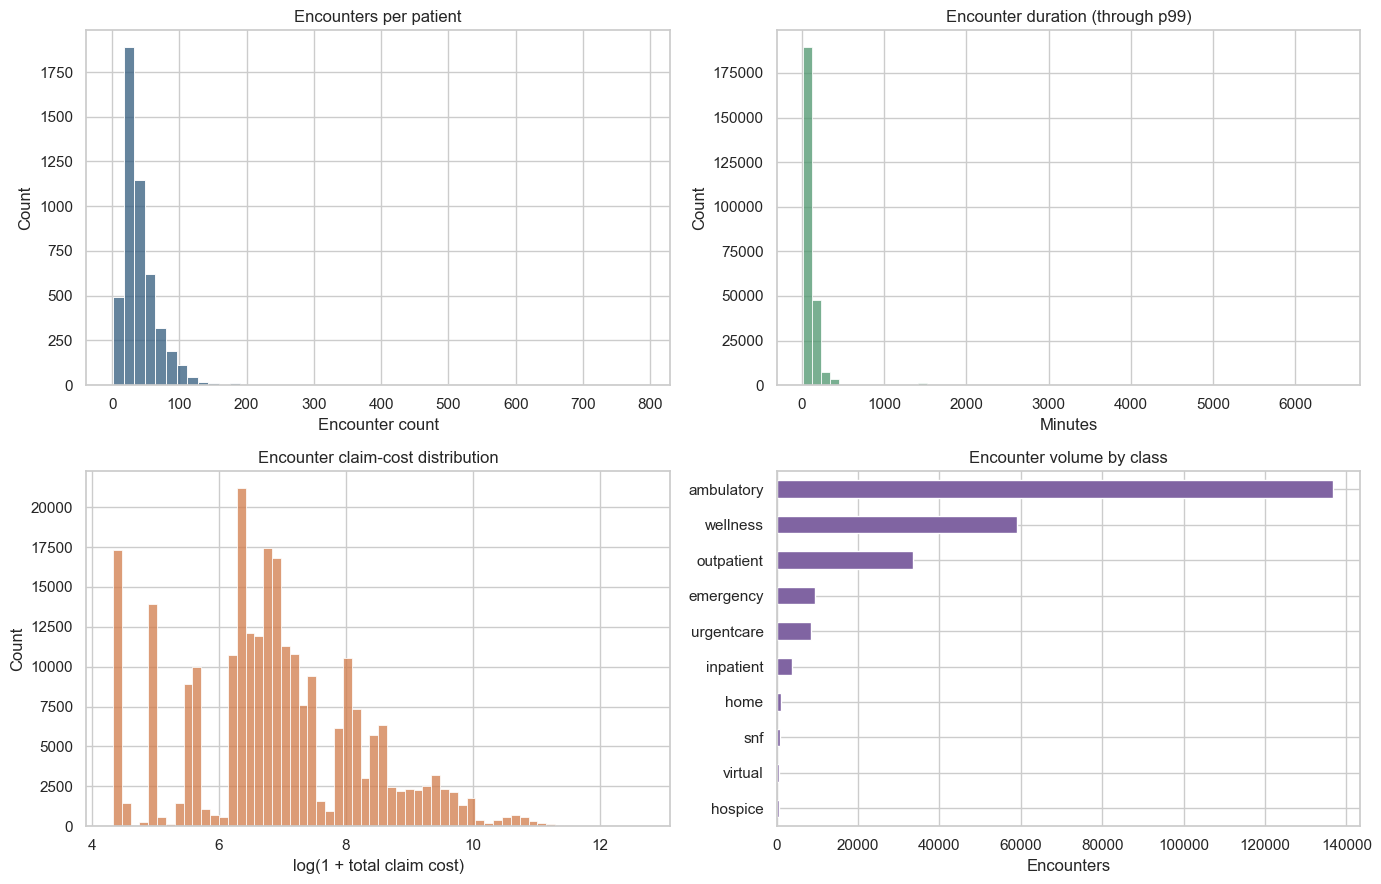

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(encounters_per_patient['encounters'], bins=50, ax=axes[0, 0], color='#315b7d')
axes[0, 0].set(title='Encounters per patient', xlabel='Encounter count')
duration_cap = encounters['duration_minutes'].quantile(0.99)
sns.histplot(encounters.loc[encounters.duration_minutes <= duration_cap, 'duration_minutes'], bins=60, ax=axes[0, 1], color='#4c956c')
axes[0, 1].set(title='Encounter duration (through p99)', xlabel='Minutes')
sns.histplot(np.log1p(encounters['total_claim_cost'].clip(lower=0)), bins=60, ax=axes[1, 0], color='#d17b49')
axes[1, 0].set(title='Encounter claim-cost distribution', xlabel='log(1 + total claim cost)')
class_counts = encounters['encounter_class'].value_counts().head(10).sort_values()
class_counts.plot.barh(ax=axes[1, 1], color='#8064a2')
axes[1, 1].set(title='Encounter volume by class', xlabel='Encounters', ylabel='')
plt.tight_layout(); plt.show()

## 3. Claims and transaction distributions

The 3.97-million-row transaction fact is aggregated in PostgreSQL to one row per claim before entering pandas. This preserves claim grain and avoids an unnecessary full transaction extract.

In [5]:
claim_metrics = query_dataframe("""
WITH transaction_by_claim AS (
  SELECT claim_id, count(*) AS transaction_count,
         coalesce(sum(amount), 0) AS claim_amount,
         coalesce(sum(payments), 0) AS claim_payments,
         coalesce(sum(transfers), 0) AS claim_transfers
  FROM analytics.fact_claim_transaction
  GROUP BY claim_id
)
SELECT c.claim_id, c.encounter_id, c.patient_key, c.primary_payer_key,
       coalesce(t.transaction_count, 0) AS transaction_count,
       coalesce(t.claim_amount, 0) AS claim_amount,
       coalesce(t.claim_payments, 0) AS claim_payments,
       coalesce(t.claim_transfers, 0) AS claim_transfers
FROM analytics.fact_claim c
LEFT JOIN transaction_by_claim t ON t.claim_id = c.claim_id
""", timeout_seconds=1800)
claims_per_encounter = claim_metrics.groupby('encounter_id', as_index=False).agg(
    claim_count=('claim_id', 'size'), transaction_amount=('claim_amount', 'sum'))
claim_profiles = pd.concat({
    'claims_per_encounter': robust_summary(claims_per_encounter['claim_count']),
    'claim_value': robust_summary(claim_metrics['claim_amount']),
    'transactions_per_claim': robust_summary(claim_metrics['transaction_count']),
}, axis=1)
display(claim_profiles)
display(pd.DataFrame({'claim_value': outlier_profile(claim_metrics['claim_amount'])}))
display(concentration_shares(claim_metrics['claim_amount'], (1, 10, 100, 1000)).to_frame('share'))

,claims_per_encounter,claim_value,transactions_per_claim
count,"253,563.0000","435,751.0000","435,751.0000"
mean,1.7185,"1,922.3793",9.1017
std,1.5686,"6,504.1643",13.7499
min,1.0000,0.0000,1.0000
p01,1.0000,0.3600,2.0000
p05,1.0000,0.9100,2.0000
p25,1.0000,91.7200,4.0000
median,1.0000,259.8800,5.0000
p75,2.0000,"1,241.7200",10.0000
p95,4.0000,"8,364.9400",32.0000


,claim_value
iqr_lower_bound,"-1,633.2800"
iqr_upper_bound,"2,966.7200"
low_outliers,0.0000
high_outliers,"63,169.0000"
outlier_share,0.1450
p99_threshold,"24,031.2450"
above_p99,"4,358.0000"


,share
top_1_share,0.0004
top_10_share,0.0034
top_100_share,0.0216
top_1000_share,0.1078


,transaction_rows,mean_amount,std_amount,min_amount,q1,median,q3,p95,p99,max_amount,high_iqr_outliers,above_p99
0,1845597,453.8795,"1,619.3530",0.0000,49.8400,136,431.4000,"1,510.8940","7,425.4440","267,860.9700",113950,18456


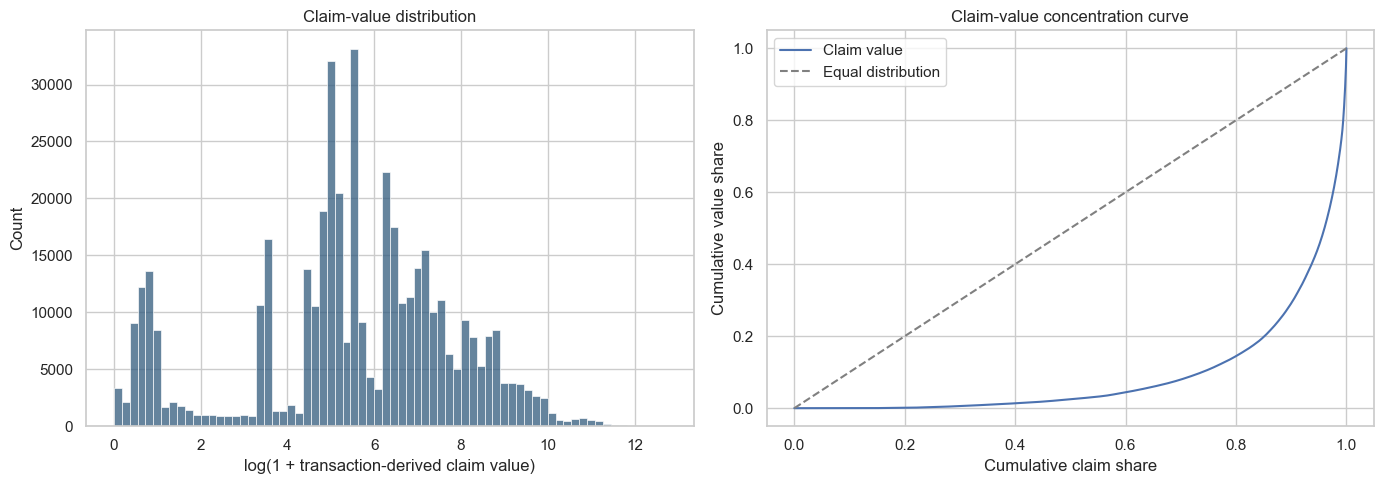

In [6]:
transaction_profile = query_dataframe("""
WITH quartiles AS (
  SELECT percentile_cont(0.25) WITHIN GROUP (ORDER BY amount) AS q1,
         percentile_cont(0.50) WITHIN GROUP (ORDER BY amount) AS median,
         percentile_cont(0.75) WITHIN GROUP (ORDER BY amount) AS q3,
         percentile_cont(0.95) WITHIN GROUP (ORDER BY amount) AS p95,
         percentile_cont(0.99) WITHIN GROUP (ORDER BY amount) AS p99
  FROM analytics.fact_claim_transaction WHERE amount IS NOT NULL
)
SELECT count(*) AS transaction_rows, avg(amount) AS mean_amount, stddev_samp(amount) AS std_amount,
       min(amount) AS min_amount, q1, median, q3, p95, p99, max(amount) AS max_amount,
       count(*) FILTER (WHERE amount > q3 + 1.5 * (q3 - q1)) AS high_iqr_outliers,
       count(*) FILTER (WHERE amount > p99) AS above_p99
FROM analytics.fact_claim_transaction CROSS JOIN quartiles
WHERE amount IS NOT NULL
GROUP BY q1, median, q3, p95, p99
""", timeout_seconds=1800)
display(transaction_profile)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.log1p(claim_metrics['claim_amount'].clip(lower=0)), bins=70, ax=axes[0], color='#315b7d')
axes[0].set(title='Claim-value distribution', xlabel='log(1 + transaction-derived claim value)')
claim_lorenz = lorenz_curve(claim_metrics['claim_amount'])
axes[1].plot(claim_lorenz.population_share, claim_lorenz.value_share, label='Claim value')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Equal distribution')
axes[1].set(title='Claim-value concentration curve', xlabel='Cumulative claim share', ylabel='Cumulative value share')
axes[1].legend(); plt.tight_layout(); plt.show()

## 4. Payer, provider, and organization variation

Rankings describe synthetic activity concentration only. They do not measure contract performance, productivity, capacity, quality, or efficiency.

,primary_payer_key,claims,total_claim_value,median_claim_value,payments,transfers,payer_key,payer_id,claim_share,value_share,payment_ratio
5,5,134687,"222,089,417.9500",171.1000,"186,906,064.5100","70,366,706.8800",5,a735bf55-83e9-331a-899d-a82a60b9f60c,0.3091,0.2651,0.8416
2,2,54597,"151,952,924.8300",507.9400,"112,521,033.7300","78,863,782.2000",2,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,0.1253,0.1814,0.7405
9,9,60818,"109,462,680.3500",278.5800,"108,511,734.3000","1,901,892.1000",9,df166300-5a78-3502-a46a-832842197811,0.1396,0.1307,0.9913
6,6,27901,"66,205,592.4000",292.3600,"48,611,898.7800","35,187,387.2400",6,b046940f-1664-3047-bca7-dfa76be352a4,0.0640,0.0790,0.7343
4,4,24870,"57,894,904.0000",307.4350,"43,304,252.4400","29,181,303.1200",4,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,0.0571,0.0691,0.7480
8,8,29959,"56,787,146.5900",292.3600,"46,780,778.1700","20,012,736.8400",8,d31fccc3-1767-390d-966a-22a5156f4219,0.0688,0.0678,0.8238
1,1,21298,"48,784,015.0400",292.3600,"34,167,192.2400","29,233,645.6000",1,0133f751-9229-3cfd-815f-b6d4979bdd6a,0.0489,0.0582,0.7004
0,0,35972,"47,175,305.2800",136.8000,"47,175,276.0700",58.4200,0,__UNKNOWN__,0.0826,0.0563,1.0000
3,3,21573,"41,876,558.4400",285.1600,"34,362,244.5500","15,028,627.7800",3,734afbd6-4794-363b-9bc0-6a3981533ed5,0.0495,0.0500,0.8206
7,7,24070,"35,449,435.6400",136.8000,"35,449,435.6400",0.0000,7,d18ef2e6-ef40-324c-be54-34a5ee865625,0.0552,0.0423,1.0000


,provider_encounters,organization_encounters
count,975.0000,975.0000
mean,260.0646,260.0646
std,585.0446,585.0446
min,1.0000,1.0000
p01,1.0000,1.0000
p05,1.0000,1.0000
p25,12.0000,12.0000
median,59.0000,59.0000
p75,207.5000,207.5000
p95,"1,330.8000","1,330.8000"


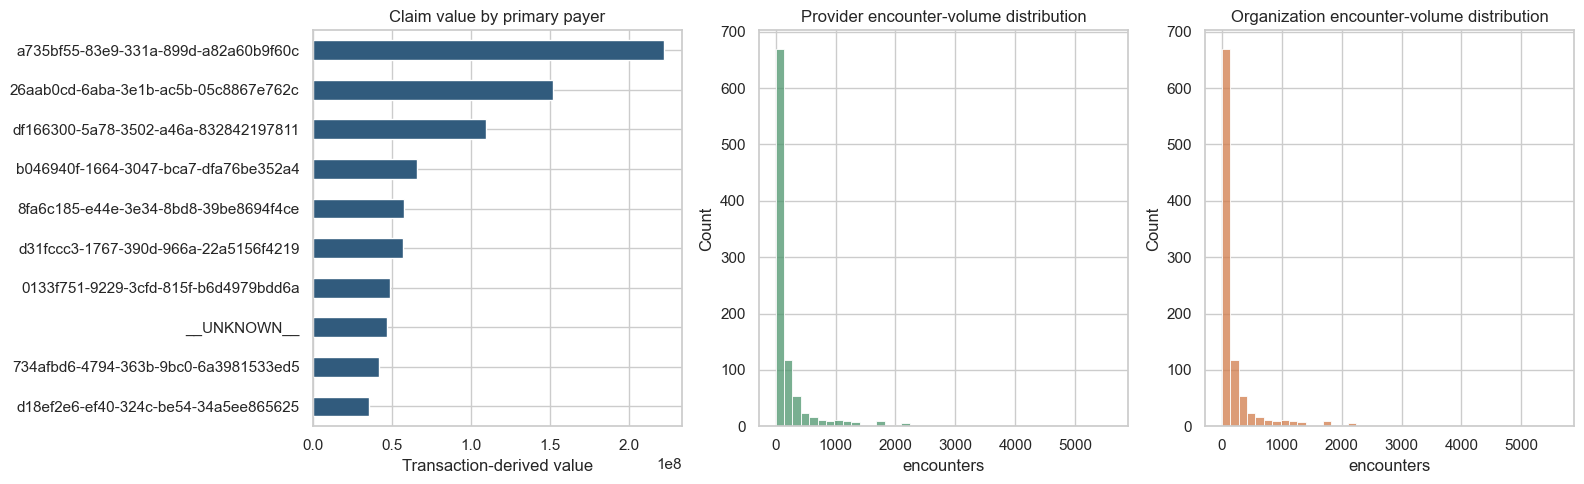

In [7]:
payer_labels = query_dataframe("SELECT payer_key, coalesce(payer_id, 'Unknown') AS payer_id FROM analytics.dim_payer")
payer_profile = claim_metrics.groupby('primary_payer_key', as_index=False).agg(
    claims=('claim_id', 'size'), total_claim_value=('claim_amount', 'sum'),
    median_claim_value=('claim_amount', 'median'), payments=('claim_payments', 'sum'),
    transfers=('claim_transfers', 'sum'))
payer_profile = payer_profile.merge(payer_labels, left_on='primary_payer_key', right_on='payer_key', how='left')
payer_profile['claim_share'] = payer_profile['claims'] / payer_profile['claims'].sum()
payer_profile['value_share'] = payer_profile['total_claim_value'] / payer_profile['total_claim_value'].sum()
payer_profile['payment_ratio'] = payer_profile['payments'] / payer_profile['total_claim_value'].replace(0, np.nan)
display(payer_profile.sort_values('total_claim_value', ascending=False))

provider_profile = encounters.groupby('provider_key', as_index=False).agg(
    encounters=('encounter_fact_key', 'size'), total_claim_cost=('total_claim_cost', 'sum'),
    median_claim_cost=('total_claim_cost', 'median'))
organization_profile = encounters.groupby('organization_key', as_index=False).agg(
    encounters=('encounter_fact_key', 'size'), total_claim_cost=('total_claim_cost', 'sum'),
    median_claim_cost=('total_claim_cost', 'median'))
display(pd.DataFrame({
    'provider_encounters': robust_summary(provider_profile['encounters']),
    'organization_encounters': robust_summary(organization_profile['encounters']),
}))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
payer_profile.nlargest(10, 'total_claim_value').sort_values('total_claim_value').plot.barh(
    x='payer_id', y='total_claim_value', legend=False, ax=axes[0], color='#315b7d')
axes[0].set(title='Claim value by primary payer', xlabel='Transaction-derived value', ylabel='')
sns.histplot(provider_profile['encounters'], bins=40, ax=axes[1], color='#4c956c')
axes[1].set(title='Provider encounter-volume distribution')
sns.histplot(organization_profile['encounters'], bins=40, ax=axes[2], color='#d17b49')
axes[2].set(title='Organization encounter-volume distribution')
plt.tight_layout(); plt.show()

## 5. Clinical utilization distributions

Occurrence, frequency, and source base cost do not establish prevalence, efficacy, quality, workload, reimbursement, or clinical value.

,procedure_occurrences,procedure_base_cost,condition_occurrences
count,392.0000,392.0000,295.0000
mean,"1,776.0255","1,828,530.6549",540.1627
std,"6,026.9496","7,059,983.9799","2,239.5822"
min,1.0000,34.3200,1.0000
p01,1.0000,240.1457,1.0000
p05,1.0000,431.4000,1.0000
p25,11.0000,"6,039.6000",11.5000
median,98.0000,"61,905.9000",67.0000
p75,679.5000,"654,802.3200",235.5000
p95,"11,897.1500","9,831,649.1400","2,313.4000"


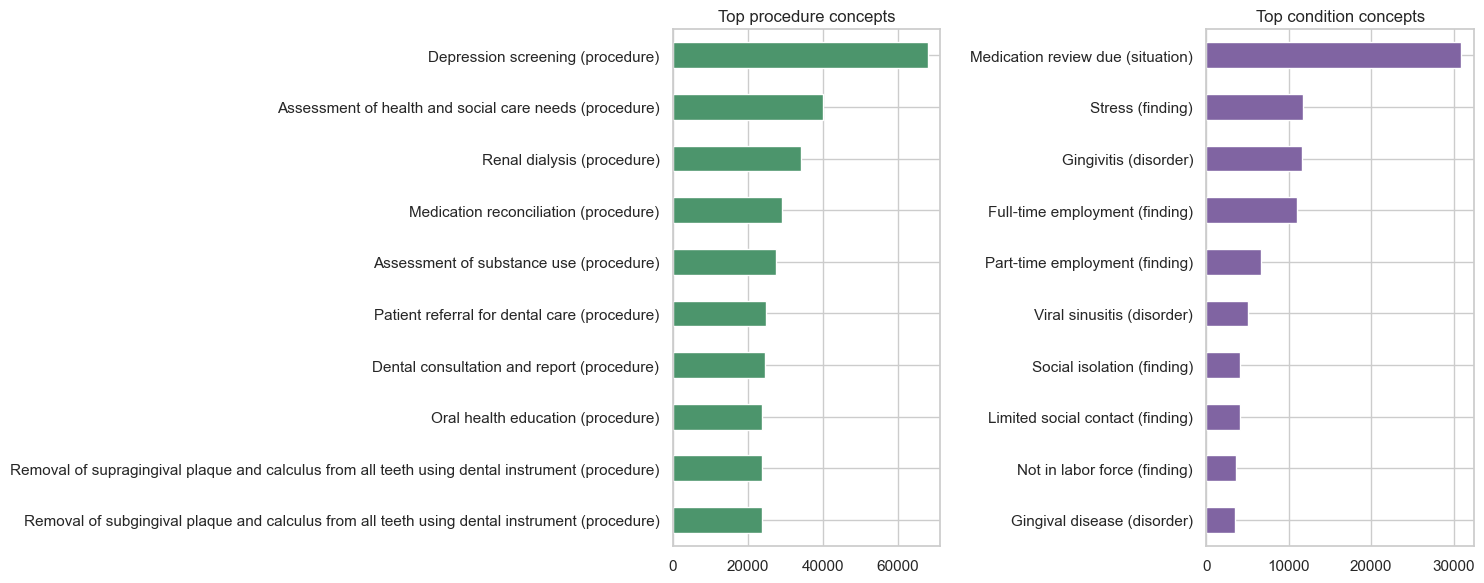

In [8]:
procedure_concepts = query_dataframe("""
SELECT p.procedure_key, d.procedure_description, count(*) AS occurrences,
       coalesce(sum(p.base_cost), 0) AS base_cost
FROM analytics.fact_procedure p
JOIN analytics.dim_procedure d ON d.procedure_key = p.procedure_key
GROUP BY p.procedure_key, d.procedure_description
""")
condition_concepts = query_dataframe("""
SELECT c.condition_key, d.condition_description, count(*) AS occurrences,
       count(DISTINCT c.patient_key) AS patients
FROM analytics.fact_condition_occurrence c
JOIN analytics.dim_condition d ON d.condition_key = c.condition_key
GROUP BY c.condition_key, d.condition_description
""")
display(pd.DataFrame({
    'procedure_occurrences': robust_summary(procedure_concepts['occurrences']),
    'procedure_base_cost': robust_summary(procedure_concepts['base_cost']),
    'condition_occurrences': robust_summary(condition_concepts['occurrences']),
}))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
procedure_concepts.nlargest(10, 'occurrences').sort_values('occurrences').plot.barh(
    x='procedure_description', y='occurrences', legend=False, ax=axes[0], color='#4c956c')
condition_concepts.nlargest(10, 'occurrences').sort_values('occurrences').plot.barh(
    x='condition_description', y='occurrences', legend=False, ax=axes[1], color='#8064a2')
axes[0].set(title='Top procedure concepts', ylabel='')
axes[1].set(title='Top condition concepts', ylabel='')
plt.tight_layout(); plt.show()

## 6. Monthly activity and volatility

Each fact is aggregated independently to month before the monthly series are combined. Synthetic peaks are not real hospital seasonality or operational shocks.

,metric,mean,std,coefficient_of_variation
0,encounters,234.1302,495.2016,2.1151
1,claims,402.3555,854.9346,2.1248
2,transaction_amount,"773,479.8557","1,837,532.9670",2.3757


,month,encounters,claims,transaction_amount
1018,2021-04-01,2762,4058,"6,683,723.4500"
1017,2021-03-01,2493,4126,"6,313,190.8900"
1079,2026-05-01,1853,3373,"7,194,615.8200"


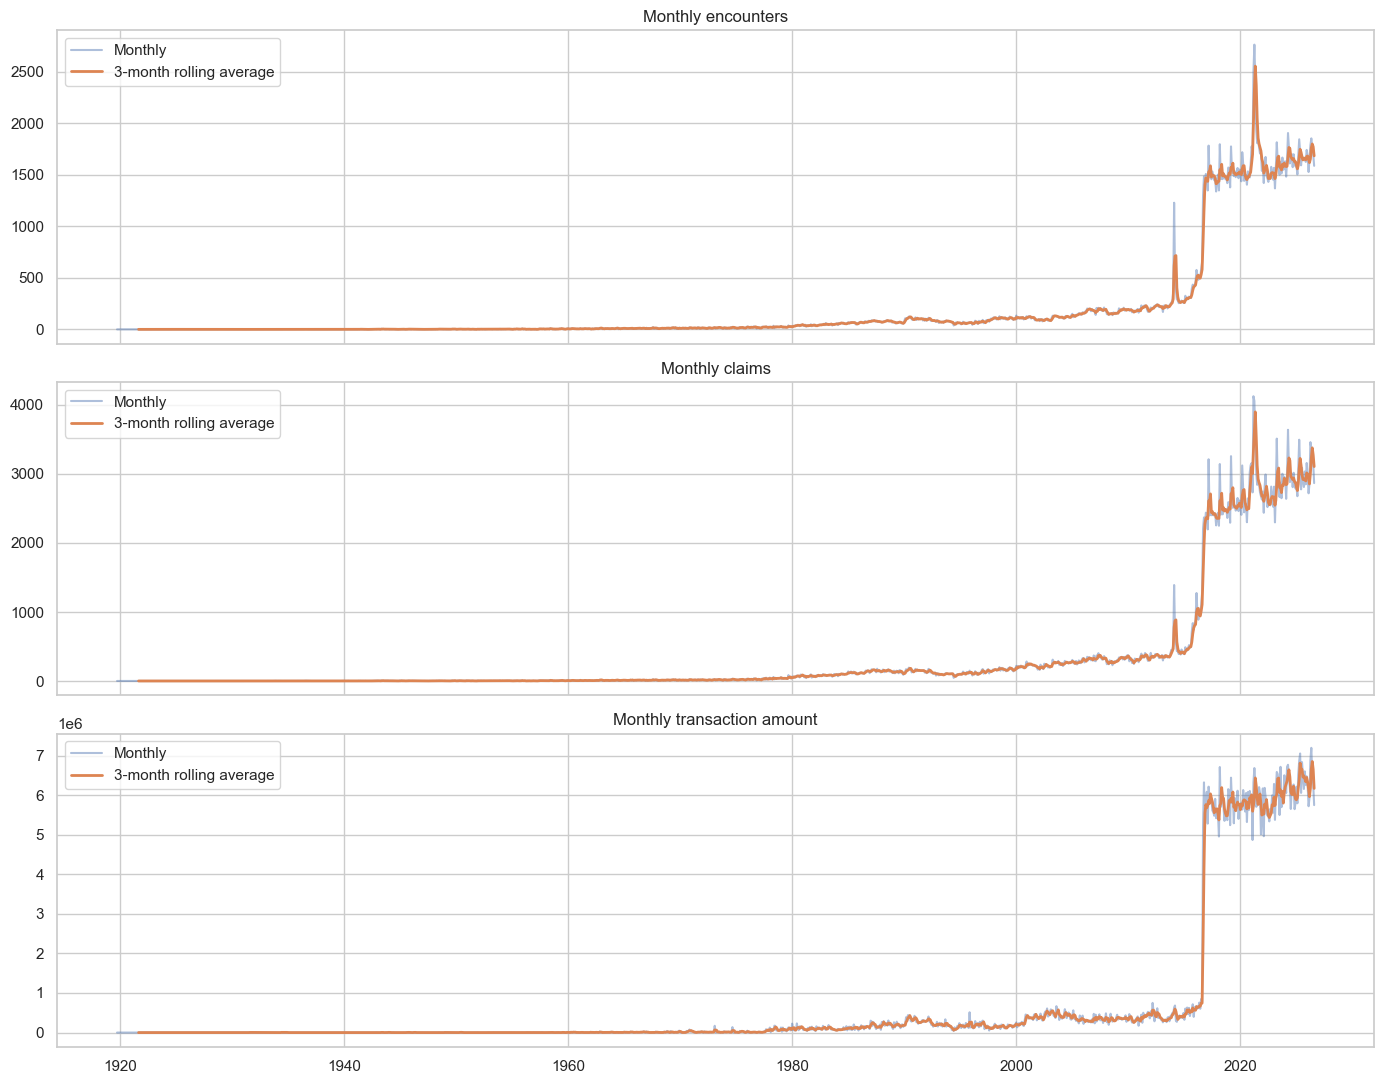

In [9]:
monthly = query_dataframe("""
WITH encounter_month AS (
  SELECT date_trunc('month', start_at)::date AS month, count(*) AS encounters
  FROM analytics.fact_encounter GROUP BY 1
), claim_month AS (
  SELECT date_trunc('month', service_at)::date AS month, count(*) AS claims
  FROM analytics.fact_claim GROUP BY 1
), transaction_month AS (
  SELECT date_trunc('month', from_at)::date AS month, coalesce(sum(amount), 0) AS transaction_amount
  FROM analytics.fact_claim_transaction GROUP BY 1
), months AS (
  SELECT month FROM encounter_month UNION SELECT month FROM claim_month UNION SELECT month FROM transaction_month
)
SELECT m.month, coalesce(e.encounters, 0) AS encounters, coalesce(c.claims, 0) AS claims,
       coalesce(t.transaction_amount, 0) AS transaction_amount
FROM months m
LEFT JOIN encounter_month e USING (month)
LEFT JOIN claim_month c USING (month)
LEFT JOIN transaction_month t USING (month)
WHERE m.month IS NOT NULL
ORDER BY m.month
""", timeout_seconds=1800)
monthly = add_monthly_diagnostics(monthly, ['encounters', 'claims', 'transaction_amount'])
display(volatility_summary(monthly, ['encounters', 'claims', 'transaction_amount']))
display(monthly.loc[[monthly.encounters.idxmax(), monthly.claims.idxmax(), monthly.transaction_amount.idxmax()],
                    ['month', 'encounters', 'claims', 'transaction_amount']].drop_duplicates())
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, metric, title in zip(axes, ['encounters', 'claims', 'transaction_amount'],
                             ['Monthly encounters', 'Monthly claims', 'Monthly transaction amount']):
    ax.plot(monthly.month, monthly[metric], alpha=.45, label='Monthly')
    ax.plot(monthly.month, monthly[f'{metric}_rolling_3m'], linewidth=2, label='3-month rolling average')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 7. Associations

Pearson and Spearman coefficients are descriptive associations only. Procedure rows are first aggregated to encounter grain before joining to the encounter fact, preventing amount multiplication. The 20,000-row scatter sample below is deterministic and used only for visualization; reported correlations use all eligible rows.

,left,right,n,pearson,spearman
0,duration_minutes,total_claim_cost,253563,0.3232,0.3325
1,base_encounter_cost,total_claim_cost,253563,0.0933,0.1927
2,total_claim_cost,payer_coverage,253563,0.9411,0.6164
3,claim_count,transaction_amount,253563,0.3431,0.1131
4,procedure_count,total_claim_cost,253563,0.4160,0.6348
5,procedure_base_cost,total_claim_cost,253563,0.9512,0.8310


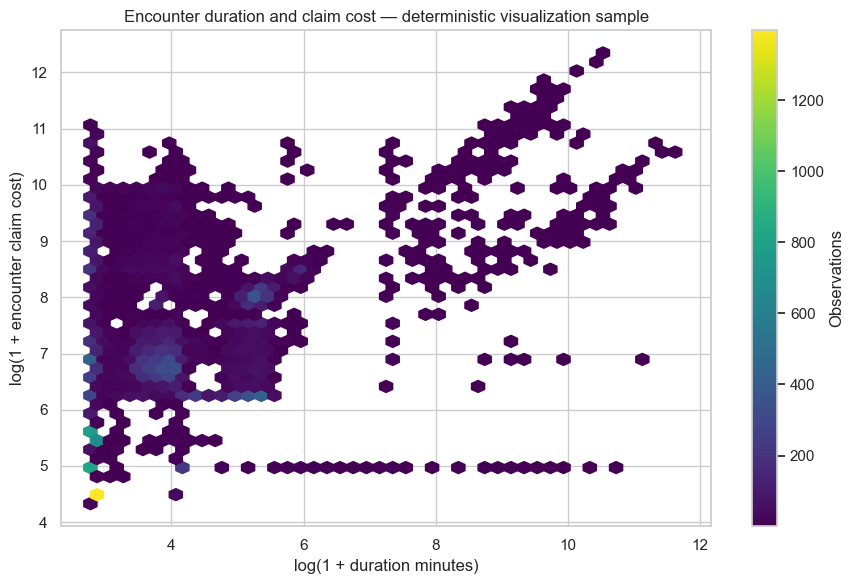

In [10]:
procedure_encounter = query_dataframe("""
WITH procedure_by_encounter AS (
  SELECT encounter_id, count(*) AS procedure_count, coalesce(sum(base_cost), 0) AS procedure_base_cost
  FROM analytics.fact_procedure GROUP BY encounter_id
)
SELECT e.encounter_id, e.total_claim_cost, e.base_encounter_cost,
       coalesce(p.procedure_count, 0) AS procedure_count,
       coalesce(p.procedure_base_cost, 0) AS procedure_base_cost
FROM analytics.fact_encounter e
LEFT JOIN procedure_by_encounter p ON p.encounter_id = e.encounter_id
""")
encounter_associations = correlation_table(encounters, [
    ('duration_minutes', 'total_claim_cost'),
    ('base_encounter_cost', 'total_claim_cost'),
    ('total_claim_cost', 'payer_coverage'),
])
claim_associations = correlation_table(claims_per_encounter, [('claim_count', 'transaction_amount')])
procedure_associations = correlation_table(procedure_encounter, [
    ('procedure_count', 'total_claim_cost'),
    ('procedure_base_cost', 'total_claim_cost'),
])
associations = pd.concat([encounter_associations, claim_associations, procedure_associations], ignore_index=True)
display(associations)
sample = encounters[['duration_minutes', 'total_claim_cost']].dropna().sample(
    n=min(20_000, encounters[['duration_minutes', 'total_claim_cost']].dropna().shape[0]),
    random_state=RANDOM_SEED)
plt.figure(figsize=(9, 6))
plt.hexbin(np.log1p(sample.duration_minutes.clip(lower=0)),
           np.log1p(sample.total_claim_cost.clip(lower=0)), gridsize=45, mincnt=1, cmap='viridis')
plt.colorbar(label='Observations')
plt.xlabel('log(1 + duration minutes)'); plt.ylabel('log(1 + encounter claim cost)')
plt.title('Encounter duration and claim cost — deterministic visualization sample')
plt.tight_layout(); plt.show()

## 8. Reproducible result summary

No outliers are removed. They remain classified as expected high-value synthetic activity, possible synthetic anomaly, or requiring investigation based on context. The 547 known non-sentinel date-order warnings remain **To Be Validated** and are not silently reclassified here.

In [11]:
eda_summary = {
    'patients': int(encounters_per_patient.shape[0]),
    'encounters_per_patient_median': float(encounters_per_patient.encounters.median()),
    'encounters_per_patient_p95': float(encounters_per_patient.encounters.quantile(.95)),
    'duration_median_minutes': float(encounters.duration_minutes.median()),
    'duration_p99_minutes': float(encounters.duration_minutes.quantile(.99)),
    'encounter_cost_median': float(encounters.total_claim_cost.median()),
    'encounter_cost_p99': float(encounters.total_claim_cost.quantile(.99)),
    'claim_value_median': float(claim_metrics.claim_amount.median()),
    'claim_value_p99': float(claim_metrics.claim_amount.quantile(.99)),
    'claim_value_top_1pct_share': float(claim_metrics.nlargest(max(1, round(len(claim_metrics) * .01)), 'claim_amount').claim_amount.sum() / claim_metrics.claim_amount.sum()),
    'unknown_payer_claim_share': float((claim_metrics.primary_payer_key == 0).mean()),
    'provider_volume_cv': float(provider_profile.encounters.std() / provider_profile.encounters.mean()),
    'organization_volume_cv': float(organization_profile.encounters.std() / organization_profile.encounters.mean()),
    'procedure_top_10_share': float(procedure_concepts.nlargest(10, 'occurrences').occurrences.sum() / procedure_concepts.occurrences.sum()),
    'condition_top_10_share': float(condition_concepts.nlargest(10, 'occurrences').occurrences.sum() / condition_concepts.occurrences.sum()),
    'peak_encounter_month': str(monthly.loc[monthly.encounters.idxmax(), 'month'].date()),
    'peak_transaction_month': str(monthly.loc[monthly.transaction_amount.idxmax(), 'month'].date()),
}
print('EDA_SUMMARY')
for key, value in eda_summary.items():
    print(f'{key}={value}')
print('ASSOCIATIONS')
print(associations.to_csv(index=False))

EDA_SUMMARY
patients=5000
encounters_per_patient_median=34.0
encounters_per_patient_p95=106.0
duration_median_minutes=41.9
duration_p99_minutes=6471.0
encounter_cost_median=919.9
encounter_cost_p99=37200.24860000015
claim_value_median=259.88
claim_value_p99=24031.245000000003
claim_value_top_1pct_share=0.26511090914141794
unknown_payer_claim_share=0.08255173252614452
provider_volume_cv=2.2496125432181078
organization_volume_cv=2.2496125432181078
procedure_top_10_share=0.4593178416608973
condition_top_10_share=0.5793922735145719
peak_encounter_month=2021-04-01
peak_transaction_month=2026-05-01
ASSOCIATIONS
left,right,n,pearson,spearman
duration_minutes,total_claim_cost,253563,0.3231567706267426,0.33253424174319296
base_encounter_cost,total_claim_cost,253563,0.09333555929050832,0.1926990961257737
total_claim_cost,payer_coverage,253563,0.9411232323038584,0.6164142671981283
claim_count,transaction_amount,253563,0.3430740636020758,0.11313983409328464
procedure_count,total_claim_cost,253563,